Fabric Defect Detection and Localisation
Using Deep Neural Networks

Step 1: Setup & Load Images

In [ ]:
import cv2, os, glob, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)   # should print "cuda" now

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns"   # adjust if your folder name differs

defect_dir = os.path.join(base_dir, "Train", "defective")
defect_free_dir = os.path.join(base_dir, "Train", "defect_free")

defect_images = sorted(glob.glob(os.path.join(defect_dir, "*.png")))
defect_free_images = sorted(glob.glob(os.path.join(defect_free_dir, "*.png")))

print(f"Defective images: {len(defect_images)}")
print(f"Defect-free images: {len(defect_free_images)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Defective images: 74
Defect-free images: 99


In [ ]:
def generate_pseudo_mask(img_path, blur_ksize=25):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    background = cv2.medianBlur(img, blur_ksize)
    residual = cv2.absdiff(img, background)
    residual = cv2.normalize(residual, None, 0, 255, cv2.NORM_MINMAX)
    _, mask = cv2.threshold(residual, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return img, mask

In [ ]:
data_pairs = []
for path in defect_images:
    img, mask = generate_pseudo_mask(path)
    data_pairs.append((img, mask))
for path in defect_free_images:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = np.zeros_like(img)
    data_pairs.append((img, mask))

print(f"Total image-mask pairs created: {len(data_pairs)}")   # should be 173

Total image-mask pairs created: 173


In [ ]:
def create_patches(image, mask, patch_size=128):
    h, w = image.shape
    patches_img, patches_mask = [], []
    for x in range(0, w, patch_size):
        if x + patch_size > w:
            x = max(0, w - patch_size)
        img_patch = image[:, x:x+patch_size]
        mask_patch = mask[:, x:x+patch_size]
        if img_patch.shape[1] == patch_size:
            patches_img.append(img_patch)
            patches_mask.append(mask_patch)
    return patches_img, patches_mask

all_img_patches, all_mask_patches = [], []
for img, mask in data_pairs:
    pi, pm = create_patches(img, mask, patch_size=128)
    all_img_patches.extend(pi)
    all_mask_patches.extend(pm)

print(f"Total patches generated: {len(all_img_patches)}")   # should be 5534

Total patches generated: 5534


In [ ]:
class FabricDataset(Dataset):
    def __init__(self, images, masks):
        self.images, self.masks = images, masks
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0
        mask = (self.masks[idx] > 127).astype(np.float32)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(mask).unsqueeze(0)

combined = list(zip(all_img_patches, all_mask_patches))
random.shuffle(combined)
all_img_patches, all_mask_patches = zip(*combined)

split = int(0.85 * len(all_img_patches))
train_ds = FabricDataset(all_img_patches[:split], all_mask_patches[:split])
val_ds = FabricDataset(all_img_patches[split:], all_mask_patches[split:])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)   # GPU-ல batch size 8 fine
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Train: 4703, Val: 831


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32,64,128,256]):
        super().__init__()
        self.downs = nn.ModuleList(); self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        c = in_channels
        for f in features:
            self.downs.append(DoubleConv(c, f)); c = f
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.ups.append(DoubleConv(f*2, f))
        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[i+1](x)
        return self.final_conv(x)

model = UNet(in_channels=1, out_channels=1).to(device)
print(sum(p.numel() for p in model.parameters()), "parameters")

7765409 parameters


In [ ]:
def dice_loss(preds, targets, eps=1e-7):
    preds = torch.sigmoid(preds).view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return 1 - (2*intersection + eps) / (preds.sum() + targets.sum() + eps)

def combined_loss(preds, targets):
    return nn.BCEWithLogitsLoss()(preds, targets) + dice_loss(preds, targets)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = combined_loss(model(imgs), masks)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

best_loss = float('inf')
patience = 3
patience_counter = 0
max_epochs = 15

for epoch in range(max_epochs):
    avg_loss = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1}/{max_epochs}, Loss: {avg_loss:.4f}")
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(base_dir, "unet_model.pth"))
        print("  -> New best model saved")
    else:
        patience_counter += 1
        print(f"  -> No improvement ({patience_counter}/{patience})")
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Epoch 1/15, Loss: 1.0428
  -> New best model saved
Epoch 2/15, Loss: 1.0039
  -> New best model saved
Epoch 3/15, Loss: 0.9844
  -> New best model saved
Epoch 4/15, Loss: 0.9719
  -> New best model saved
Epoch 5/15, Loss: 0.9570
  -> New best model saved
Epoch 6/15, Loss: 0.9518
  -> New best model saved
Epoch 7/15, Loss: 0.9446
  -> New best model saved
Epoch 8/15, Loss: 0.9400
  -> New best model saved
Epoch 9/15, Loss: 0.9406
  -> No improvement (1/3)
Epoch 10/15, Loss: 0.9360
  -> New best model saved
Epoch 11/15, Loss: 0.9303
  -> New best model saved
Epoch 12/15, Loss: 0.9304
  -> No improvement (1/3)
Epoch 13/15, Loss: 0.9326
  -> No improvement (2/3)
Epoch 14/15, Loss: 0.9322
  -> No improvement (3/3)
Early stopping at epoch 14


In [ ]:
def compute_iou_dice(preds, targets, eps=1e-7):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum() + targets.sum() + eps)
    return iou.item(), dice.item()

model.eval()
total_iou, total_dice, num_batches = 0, 0, 0

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        predicted_mask = (torch.sigmoid(model(imgs)) > 0.5).float()
        iou, dice = compute_iou_dice(predicted_mask, masks)
        total_iou += iou
        total_dice += dice
        num_batches += 1

print(f"Average IoU:  {total_iou/num_batches:.4f}")
print(f"Average Dice: {total_dice/num_batches:.4f}")

# Also check: is the model predicting ANY defect pixels at all?
total_predicted_positive = 0
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(device)
        predicted_mask = (torch.sigmoid(model(imgs)) > 0.5).float()
        total_predicted_positive += predicted_mask.sum().item()

print(f"Total predicted defect pixels across validation set: {total_predicted_positive}")

Average IoU:  0.6569
Average Dice: 0.6770
Total predicted defect pixels across validation set: 28689.0


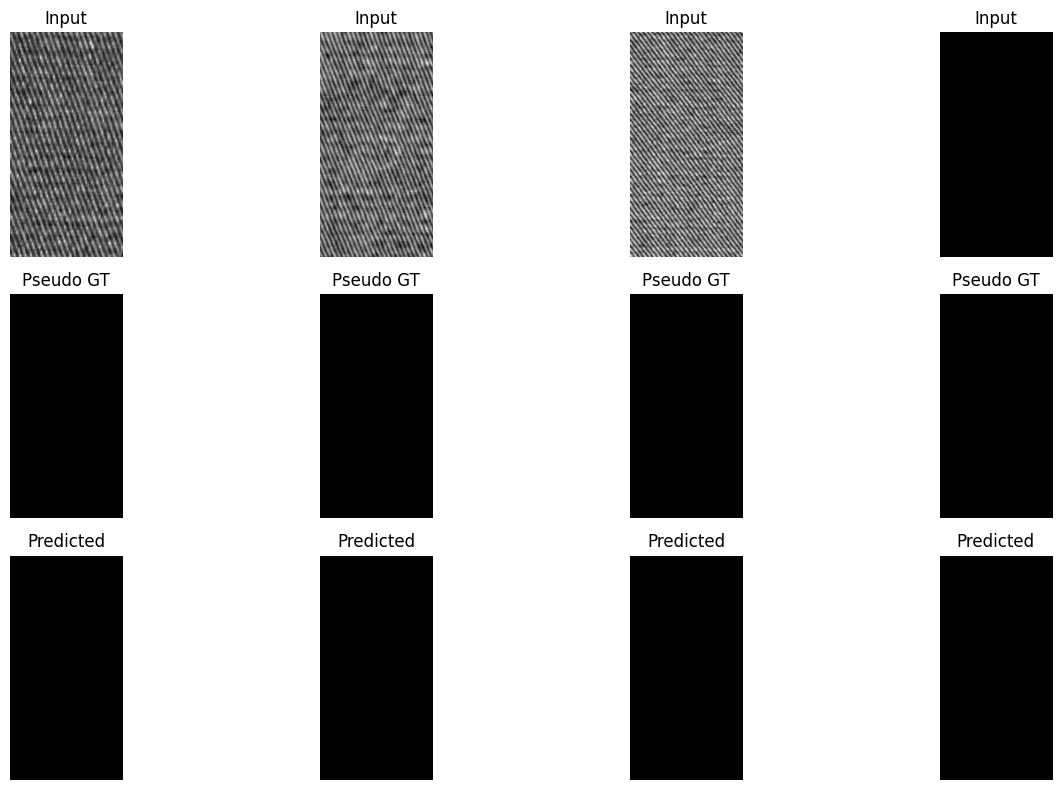

In [ ]:
model.eval()
with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs = imgs.to(device)
    predicted_masks = (torch.sigmoid(model(imgs)) > 0.5).float()

num_samples = min(4, imgs.shape[0])
fig, axes = plt.subplots(3, num_samples, figsize=(14, 8))
for i in range(num_samples):
    axes[0, i].imshow(imgs[i][0].cpu(), cmap='gray'); axes[0, i].set_title("Input"); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i][0].cpu(), cmap='gray'); axes[1, i].set_title("Pseudo GT"); axes[1, i].axis('off')
    axes[2, i].imshow(predicted_masks[i][0].cpu(), cmap='gray'); axes[2, i].set_title("Predicted"); axes[2, i].axis('off')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/final_comparison.png", dpi=150)
plt.show()

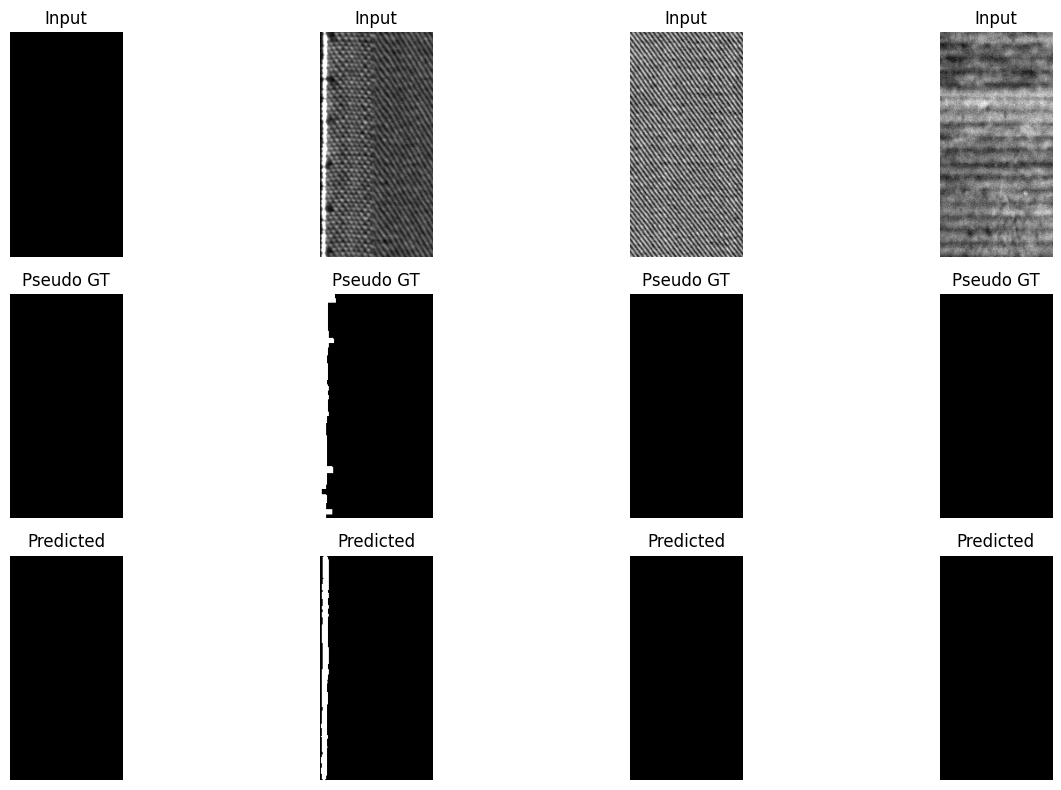

In [ ]:
# Find a validation batch that actually contains a defective patch
model.eval()
found_defect_sample = False

with torch.no_grad():
    for imgs, masks in val_loader:
        if masks.sum() > 0:   # this batch has at least one defect patch
            imgs, masks = imgs.to(device), masks.to(device)
            predicted_masks = (torch.sigmoid(model(imgs)) > 0.5).float()
            found_defect_sample = True
            break

if found_defect_sample:
    num_samples = min(4, imgs.shape[0])
    fig, axes = plt.subplots(3, num_samples, figsize=(14, 8))
    for i in range(num_samples):
        axes[0, i].imshow(imgs[i][0].cpu(), cmap='gray'); axes[0, i].set_title("Input"); axes[0, i].axis('off')
        axes[1, i].imshow(masks[i][0].cpu(), cmap='gray'); axes[1, i].set_title("Pseudo GT"); axes[1, i].axis('off')
        axes[2, i].imshow(predicted_masks[i][0].cpu(), cmap='gray'); axes[2, i].set_title("Predicted"); axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No defect patches found in validation set - unexpected!")

In [ ]:
# Save predicted masks + ground truth masks as actual image files (for report/proof)
os.makedirs("/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/predicted_masks", exist_ok=True)
os.makedirs("/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/ground_truth_masks", exist_ok=True)

model.eval()
idx = 0
with torch.no_grad():
    for imgs, masks in val_loader:                          # loop through validation batches
        imgs = imgs.to(device)
        predicted = (torch.sigmoid(model(imgs)) > 0.5).float()   # model's predicted mask

        for i in range(imgs.shape[0]):                       # save each image in the batch separately
            pred_np = (predicted[i][0].cpu().numpy() * 255).astype(np.uint8)   # convert to 0-255 image
            gt_np = (masks[i][0].cpu().numpy() * 255).astype(np.uint8)         # convert ground truth too

            cv2.imwrite(f"/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/predicted_masks/pred_{idx}.png", pred_np)
            cv2.imwrite(f"/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/ground_truth_masks/gt_{idx}.png", gt_np)
            idx += 1

print(f"Saved {idx} predicted masks and {idx} ground truth masks to Drive")

Saved 831 predicted masks and 831 ground truth masks to Drive


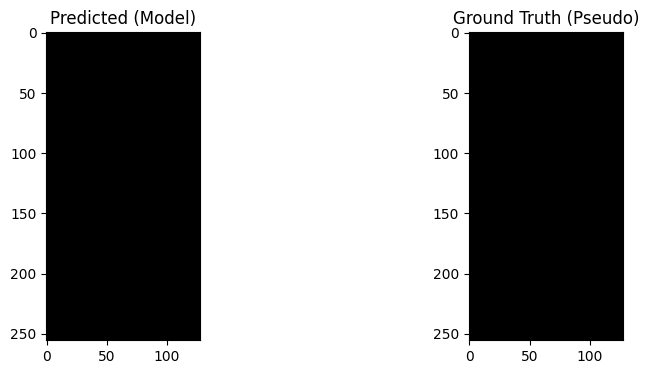

In [ ]:
# Load a specific pair and compare visually
pred = cv2.imread("/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/predicted_masks/pred_10.png", cv2.IMREAD_GRAYSCALE)
gt = cv2.imread("/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/ground_truth_masks/gt_10.png", cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(pred, cmap='gray'); ax[0].set_title("Predicted (Model)")
ax[1].imshow(gt, cmap='gray'); ax[1].set_title("Ground Truth (Pseudo)")
plt.show()

### Visualize more predicted and ground truth masks

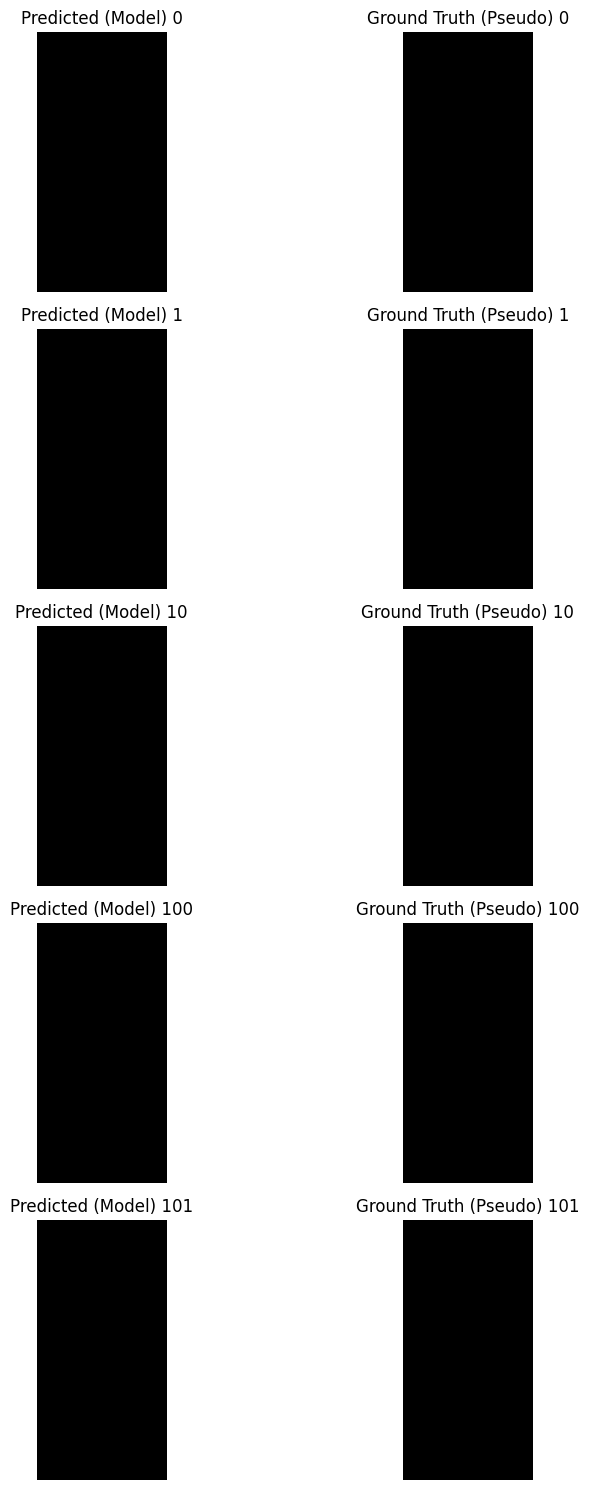

In [1]:
import matplotlib.pyplot as plt
import cv2
import os

predicted_masks_dir = "/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/predicted_masks"
ground_truth_masks_dir = "/content/drive/MyDrive/CO5420_NEURALPROJECT/co-5420-fabric-defect-detection-using-n-ns/ground_truth_masks"

# Get a list of all saved predicted mask files
pred_files = sorted(os.listdir(predicted_masks_dir))

# Display a few examples (e.g., first 5 or 10)
num_examples_to_display = 5

fig, axes = plt.subplots(num_examples_to_display, 2, figsize=(10, num_examples_to_display * 3))

for i in range(num_examples_to_display):
    if i >= len(pred_files): # Check if there are enough files
        break

    # Extract index from filename (e.g., 'pred_0.png' -> 0)
    file_idx = int(pred_files[i].split('_')[1].split('.')[0])

    pred_path = os.path.join(predicted_masks_dir, f"pred_{file_idx}.png")
    gt_path = os.path.join(ground_truth_masks_dir, f"gt_{file_idx}.png")

    pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    if pred is not None and gt is not None:
        axes[i, 0].imshow(pred, cmap='gray')
        axes[i, 0].set_title(f"Predicted (Model) {file_idx}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt, cmap='gray')
        axes[i, 1].set_title(f"Ground Truth (Pseudo) {file_idx}")
        axes[i, 1].axis('off')
    else:
        print(f"Could not load images for index {file_idx}")

plt.tight_layout()
plt.show()